<a href="https://colab.research.google.com/github/Jsanch1020/is201/blob/main/Ex15-TestingCAPM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Investments: Theory and Data Analysis**, Bates, Boyer, and Fletcher

# Example Chapter 15: Testing the CAPM
In this notebook we download return data from Ken French's website and estimate the CAPM alphas for each porfolio along with the 95% confidence intervals.   

### Imports and Setup

In [1]:
%pip install -q simple-finance
import simple_finance as sf
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

### Choose Strategy and Estimate Alpha
In the block of code below we use the function `get_ff_strategies` which downloads the historical returns on various trading strategies from Ken French's website, along with the return on the market value-weighted portfolio and the return on short-term t-bills. These strategies are based on decile-sorts. See `Ex07-Ken_French.ipynb` for more details.    


In [2]:
# Choose the strategy
# Import all available monthly data
dat=sf.get_ff_strategies(stype='momentum',details=True)

# Initialize lists to store intercepts and confidence intervals
intercepts = []
conf_intervals = []

# Loop through each column corresponding to Dec 1 - Dec 10
for column in [f"Dec {i}" for i in range(1, 11)]:
    y = dat[column]-dat['rf']  # Dependent variable (Decile return)
    X = dat['mkt-rf']  # Independent variable (Market excess return)
    X = sm.add_constant(X)    # Add constant to X for intercept

    # Fit regression model
    model = sm.OLS(y, X).fit()

    # Get the intercept and 95% confidence intervals
    intercept = model.params['const'] * 12  # Multiply intercept by 12 to annualize
    ci_lower, ci_upper = model.conf_int().iloc[0] * 12  # Multiply confidence intervals by 12 to annualize

    # Get the intercept and 95% confidence intervals
    intercepts.append(intercept)  # Append intercept to list
    conf_intervals.append([ci_lower, ci_upper])  # Append 95% CI for the intercept

# Convert results to DataFrame for easier manipulation
results_df = pd.DataFrame({
    "Decile": [f"Dec {i}" for i in range(1, 11)],
    "Intercept": intercepts,
    "CI_Lower": [ci[0] for ci in conf_intervals],
    "CI_Upper": [ci[1] for ci in conf_intervals]
})


----------------
Momentum Strategy
----------------
Basic Strategy: stocks are sorted into deciles based on their prior 12-month returns, excluding the most recent month.

Construction: The portfolios are constructed monthly using NYSE prior (2-12) return decile breakpoints.

Stocks: The portfolios constructed each month include NYSE, AMEX, and NASDAQ stocks with prior return data.
To be included in a portfolio for month t (formed at the end of month t-1), a stock must have a price for the
end of month t-13 and a good return for t-2. In addition, any missing returns from t-12 to t-3 must be -99.0,
CRSP's code for a missing price. Each included stock also must have ME for the end of month t-1.

Min Date: 1927-01, Max Date: 2026-01


### Plot the Alphas with 95% Confidence Intervals

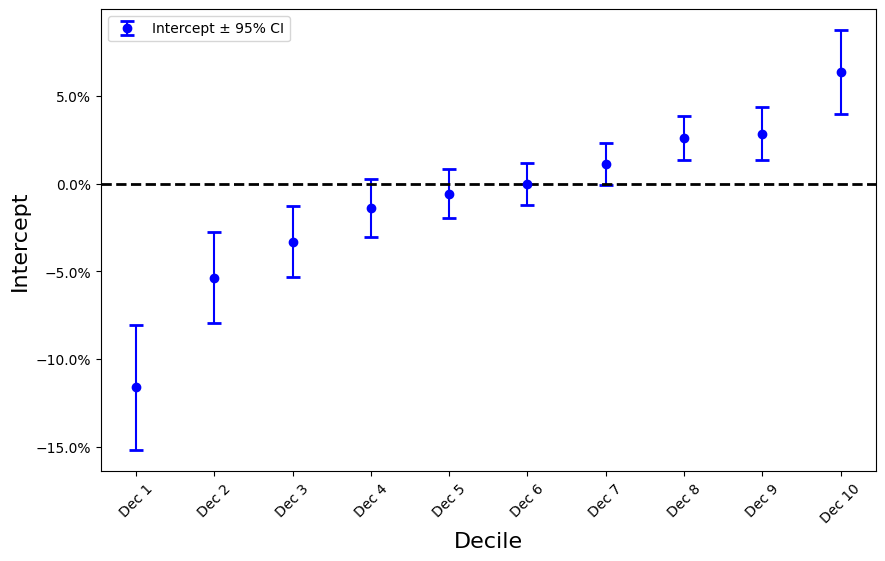

In [3]:
# Plot the intercepts with confidence intervals
plt.figure(figsize=(10, 6))
plt.errorbar(results_df["Decile"], results_df["Intercept"],
             yerr=[results_df["Intercept"] - results_df["CI_Lower"],
                   results_df["CI_Upper"] - results_df["Intercept"]],
             fmt='o', capsize=5, capthick=2, label="Intercept ± 95% CI", color='b')

# Labels and title
plt.xlabel("Decile",fontsize=16)
plt.ylabel("Intercept",fontsize=16)
#plt.title("Regression Intercepts with 95% Confidence Intervals")
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.axhline(0, color='black', linestyle='--', linewidth=2)  # Reference line at 0
plt.legend()
# Format y-axis as percentages
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))

# Show the plot
plt.show()